<center><h1><b> Vendor Performance Analysis </b></h1> </center>

## Overview

In the competitive landscape of retail and wholesale industries, effective inventory and sales management serve as the backbone of sustainable profitability. Companies operating in these sectors face huge pressure to optimize their vendor relationships, streamline inventory processes, and maximize profit margins while minimizing operational inefficiencies. Poor vendor performance, suboptimal pricing strategies, and inadequate inventory turnover can quickly erode profit margins and create cascading operational challenges that impact the entire supply chain.

Thorugh this project, I tried to address these critical business challenges through a comprehensive, data-driven approach that mirrors real-world industry practices. In this project, I approached the problems from the company-standard with end-to-end data analytics initiative that integrates multiple tools and methodologies, including SQL for database management, Python for advanced analytics, Power BI for executive-level reporting, scripting for repeating data ingestion and logging to keep track of errors, changes, and edits.

The project follows a complete ETL (Extract, Transform, Load) pipeline methodology, beginning with database creation from multiple CSV datasets (inventory records, purchase data, sales transactions, and vendor invoices), progressing through comprehensive SQL-based data exploration and aggregation, advancing to Python-powered statistical analysis and insight generation, and culminating in an interactive Power BI dashboard with actionable business recommendations.

This vendor performance analysis directly addresses the critical challenge facing modern retailers: how to systematically evaluate vendor relationships to maximize profitability while minimizing operational risks to provide stakeholders with data-driven insights necessary for strategic decision-making in vendor selection, inventory optimization, and pricing strategy development.



### Objectives

1. **Identify Underperforming Brands**: Analyze sales performance, profit margins, and market response to pinpoint brands requiring promotional campaigns, pricing adjustments, or strategic repositioning to improve profitability.

2. **Determine Top-Contributing Vendors**: Evaluate vendor performance metrics including sales volume, gross profit generation, and reliability to identify high-value partnerships worthy of expanded collaboration and preferential terms.

3. **Analyze Bulk Purchasing Impact**: Investigate the relationship between purchase volume and unit costs to optimize procurement strategies, negotiate better pricing tiers, and maximize cost savings through strategic bulk buying decisions.

4. **Assess Inventory Turnover Efficiency**: Calculate and analyze inventory turnover rates to identify slow-moving products, reduce holding costs, minimize storage expenses, and improve capital allocation efficiency.

5. **Investigate Profitability Variance**: Conduct comparative analysis between high-performing and low-performing vendors to understand key success factors, identify improvement opportunities, and develop vendor performance benchmarks.

### Technical Objectives:

- **Build End-to-End ETL Pipeline**: Create a comprehensive data processing workflow from raw CSV files through database storage to final analytical outputs
- **Integrate Multi-Tool Analysis**: Demonstrate proficiency in SQL for data extraction and transformation, Python for advanced analytics, and Power BI for executive reporting
- **Generate Actionable Insights**: Transform complex datasets into clear, business-relevant recommendations that directly address operational challenges and profit optimization opportunities

These objectives collectively aim to establish a robust vendor performance evaluation framework that supports strategic business decisions and drives sustainable profitability growth.

Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import plotly.express as px
import plotly.io as io 
import plotly.graph_objects as go 
import mysql.connector
import warnings
warnings.filterwarnings("ignore")

Checking the names of the csv files 

In [ ]:
file_name = []
file_csv = []
for file in os.listdir(r"C:\Users\p1a2r\OneDrive\Desktop\Git Hub Projects\Vendor Performance Analysis"):
    if ".csv" in file:
        print(file)
        file_name.append(file.split(".")[0])
        file_csv.append(file)
        df = pd.read_csv(r'C:\Users\p1a2r\OneDrive\Desktop\Git Hub Projects\Vendor Performance Analysis/' + file)
        print("Rows: ", df.shape[0], "Columns: ", df.shape[1], "\n")

begin_inventory.csv
Rows:  206529 Columns:  9 

end_inventory.csv
Rows:  224489 Columns:  9 

purchases.csv
Rows:  2372474 Columns:  16 

purchase_prices.csv
Rows:  12261 Columns:  9 

sales.csv
Rows:  12825363 Columns:  14 

vendor_invoice.csv
Rows:  5543 Columns:  10 



Listing the file names to use in the script to load this files into the MYSQL database.

In [13]:
 file_name

['begin_inventory',
 'end_inventory',
 'purchases',
 'purchase_prices',
 'sales',
 'vendor_invoice']

In [18]:
csv_files = []
for csv_file, csv_name in zip(file_name, file_csv):
    csv_files.append((csv_name, csv_file))

csv_files

[('begin_inventory.csv', 'begin_inventory'),
 ('end_inventory.csv', 'end_inventory'),
 ('purchases.csv', 'purchases'),
 ('purchase_prices.csv', 'purchase_prices'),
 ('sales.csv', 'sales'),
 ('vendor_invoice.csv', 'vendor_invoice')]

I used this Python script from the GitHub repository to upload multiple CSV files (including large datasets with 12.8 million rows) to a MySQL database efficiently. The script automatically drops and recreates the target database each time it runs, ensuring no duplicate data accumulates from repeated executions. It processes data in batches to handle large files without memory issues and includes robust error handling with automatic retry logic for connection problems. Before running, make sure to set your `folder_path` variable to point to the CSV files directory and update the database credentials in `DB_CONFIG` as needed.

In [ ]:
import pandas as pd
import mysql.connector
from mysql.connector import Error
import os
import time

DB_CONFIG = {
    'host': 'localhost',
    'user': 'XXX', # Enter your MySQL username here
    'password': 'XXXX', # Enter your MySQL password here
    'database': 'vendor'
}

# List of CSV files and their corresponding table names
csv_files = []
for csv_file, csv_name in zip(file_name, file_csv):
    csv_files.append((csv_name, csv_file))

# Folder containing the CSV files 
folder_path = r"C:\Users\p1a2r\OneDrive\Desktop\Git Hub Projects\Vendor Performance Analysis"  # Add your folder path here

# Configuration for batch processing
BATCH_SIZE = 1000  # Process data in batches to avoid memory/connection issues
MAX_RETRIES = 3    # Number of retries for failed operations

def get_sql_type(dtype, series=None):
    """Convert pandas dtype to appropriate MySQL data type"""
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'DOUBLE' 
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:

        if series is not None:
            max_length = series.astype(str).str.len().max()
            if pd.isna(max_length) or max_length == 0:
                return 'VARCHAR(255)'
            elif max_length <= 255:
                return f'VARCHAR({min(255, max(50, int(max_length * 1.2)))})'
            else:
                return 'TEXT'
        return 'VARCHAR(255)'

def create_connection_with_retry():
    """Create database connection with retry logic"""
    for attempt in range(MAX_RETRIES):
        try:
            # Try with SSL disabled first
            config = DB_CONFIG.copy()
            config['ssl_disabled'] = True
            conn = mysql.connector.connect(**config)
            
            # Test the connection
            cursor = conn.cursor()
            cursor.execute("SELECT 1")
            cursor.fetchone()
            cursor.close()
            print(f"Successfully connected to MySQL database (SSL disabled)")
            return conn
            
        except (Error, AttributeError) as e:
            print(f"Connection attempt {attempt + 1} with SSL disabled failed: {e}")
            
            # Try without SSL parameters if SSL-related error
            try:
                conn = mysql.connector.connect(**DB_CONFIG)
                cursor = conn.cursor()
                cursor.execute("SELECT 1")
                cursor.fetchone()
                cursor.close()
                print(f"Successfully connected to MySQL database (default SSL)")
                return conn
            except Error as e2:
                print(f"Connection attempt {attempt + 1} with default SSL failed: {e2}")
                
            if attempt < MAX_RETRIES - 1:
                print(f"Retrying in 5 seconds...")
                time.sleep(5)
            else:
                raise Exception(f"Failed to connect after {MAX_RETRIES} attempts")

def recreate_database():
    """Drop and recreate the target database"""
    init_config = DB_CONFIG.copy()
    del init_config['database']
    
    for attempt in range(MAX_RETRIES):
        try:
            # Try with SSL disabled first
            config_with_ssl_disabled = init_config.copy()
            config_with_ssl_disabled['ssl_disabled'] = True
            
            try:
                conn = mysql.connector.connect(**config_with_ssl_disabled)
            except (Error, AttributeError):
                # If SSL disabled doesn't work, try default connection
                conn = mysql.connector.connect(**init_config)
            
            cursor = conn.cursor()
            
            # Drop database if exists and create new one
            cursor.execute(f"DROP DATABASE IF EXISTS `{DB_CONFIG['database']}`")
            cursor.execute(f"CREATE DATABASE `{DB_CONFIG['database']}`")
            
            print(f"Database '{DB_CONFIG['database']}' has been recreated successfully")
            
            cursor.close()
            conn.close()
            return
            
        except Error as e:
            print(f"Database recreation attempt {attempt + 1} failed: {e}")
            if attempt < MAX_RETRIES - 1:
                print("Retrying in 5 seconds...")
                time.sleep(5)
            else:
                raise

def upload_csv_to_table(csv_file, table_name, folder_path):
    """Upload a single CSV file to a MySQL table with batch processing"""
    file_path = os.path.join(folder_path, csv_file)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} not found. Skipping...")
        return
    
    print(f"Processing {csv_file}...")
    
    try:
        # Read the CSV file into a pandas DataFrame
        df = pd.read_csv(file_path)
        
        if df.empty:
            print(f"Warning: {csv_file} is empty. Skipping...")
            return
        
        print(f"Loaded {len(df)} rows from {csv_file}")
        
        # Replace NaN with None to handle SQL NULL
        df = df.where(pd.notnull(df), None)
        
        # Clean column names
        df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]
        
        # Create connection for this table
        conn = create_connection_with_retry()
        cursor = conn.cursor()
        
        try:
            # Generate the CREATE TABLE statement
            columns = []
            for col in df.columns:
                sql_type = get_sql_type(df[col].dtype, df[col])
                columns.append(f'`{col}` {sql_type}')
            
            create_table_query = f'CREATE TABLE `{table_name}` ({", ".join(columns)})'
            cursor.execute(create_table_query)
            print(f"Created table '{table_name}'")
            
            # Prepare batch insert
            if not df.empty:
                placeholders = ', '.join(['%s'] * len(df.columns))
                columns_str = ', '.join([f'`{col}`' for col in df.columns])
                insert_query = f"INSERT INTO `{table_name}` ({columns_str}) VALUES ({placeholders})"
                
                # Process data in batches
                total_rows = len(df)
                rows_inserted = 0
                
                for start_idx in range(0, total_rows, BATCH_SIZE):
                    end_idx = min(start_idx + BATCH_SIZE, total_rows)
                    batch_df = df.iloc[start_idx:end_idx]
                    
                    # Convert batch to list of tuples
                    batch_data = []
                    for _, row in batch_df.iterrows():
                        values = tuple(None if pd.isna(x) else x for x in row)
                        batch_data.append(values)
                    
                    # Insert batch with retry logic
                    batch_inserted = False
                    for attempt in range(MAX_RETRIES):
                        try:
                            cursor.executemany(insert_query, batch_data)
                            conn.commit()
                            rows_inserted += len(batch_data)
                            batch_inserted = True
                            break
                        except Error as e:
                            print(f"Batch insert attempt {attempt + 1} failed: {e}")
                            if attempt < MAX_RETRIES - 1:
                                cursor.close()
                                conn.close()
                                conn = create_connection_with_retry()
                                cursor = conn.cursor()
                                time.sleep(2)
                            else:
                                raise
                    
                    if not batch_inserted:
                        raise Exception(f"Failed to insert batch after {MAX_RETRIES} attempts")
                
                print(f"Successfully inserted all {rows_inserted} rows into '{table_name}'")
        
        finally:
            cursor.close()
            conn.close()
            
    except Exception as e:
        print(f"Error processing {csv_file}: {e}")
        raise

def main():
    """Main function to orchestrate the data upload process"""
    print("Starting data upload process...")
    
    # Validate folder path
    if not folder_path or not os.path.exists(folder_path):
        print(f"Error: Please set a valid folder_path. Current path: '{folder_path}'")
        return
    
    try:
        # Recreate the database
        print("Step 1: Recreating database...")
        recreate_database()
        
        # Wait a bit for database to be fully ready
        time.sleep(2)
        
        # Process each CSV file
        print("Step 2: Processing CSV files...")
        for csv_file, table_name in csv_files:
            try:
                upload_csv_to_table(csv_file, table_name, folder_path)
                print(f"Completed processing {table_name}")
                # Small delay between tables
                time.sleep(1)
            except Exception as e:
                print(f"Failed to process {csv_file}: {e}")
                # Continue with next file instead of stopping entirely
                continue
        
        print("\nData upload process completed!")
        
        # Display summary
        print("\n--- Database Summary ---")
        conn = create_connection_with_retry()
        cursor = conn.cursor()
        
        try:
            for _, table_name in csv_files:
                try:
                    cursor.execute(f"SELECT COUNT(*) FROM `{table_name}`")
                    count = cursor.fetchone()[0]
                    print(f"Table '{table_name}': {count:,} rows")
                except Error:
                    print(f"Table '{table_name}': Not found or error occurred")
        finally:
            cursor.close()
            conn.close()
        
    except Exception as e:
        print(f"Error during upload process: {e}")
        raise

if __name__ == "__main__":
    main()

Starting data upload process...
Step 1: Recreating database...
Database 'vender' has been recreated successfully
Step 2: Processing CSV files...
Processing begin_inventory.csv...
Loaded 206529 rows from begin_inventory.csv
Successfully connected to MySQL database (SSL disabled)
Created table 'begin_inventory'
Successfully inserted all 206529 rows into 'begin_inventory'
Completed processing begin_inventory
Processing end_inventory.csv...
Loaded 224489 rows from end_inventory.csv
Successfully connected to MySQL database (SSL disabled)
Created table 'end_inventory'
Successfully inserted all 224489 rows into 'end_inventory'
Completed processing end_inventory
Processing purchases.csv...
Loaded 2372474 rows from purchases.csv
Successfully connected to MySQL database (SSL disabled)
Created table 'purchases'
Successfully inserted all 2372474 rows into 'purchases'
Completed processing purchases
Processing purchase_prices.csv...
Loaded 12261 rows from purchase_prices.csv
Successfully connected t

Creating a logging to record the warnings, errors, information and know the steps completed to monitor the results

In [ ]:
!pip install -qqq logging
import logging
logging.basicConfig(
    filename= r"C:\Users\p1a2r\OneDrive\Desktop\Git Hub Projects\Vendor Performance Analysis\log/ingest_db.log",
    level = logging.DEBUG,
    format= "%(asctime)s - %(levelname)s - %(message)s",
    filemode= "a"
)

In [ ]:
import time

def load_raw_data():
    file_name = []
    file_csv = []
    start = time.time()
    for file in os.listdir(r"C:\Users\p1a2r\OneDrive\Desktop\Git Hub Projects\Vendor Performance Analysis"):
    if ".csv" in file:
        print(file)
        file_name.append(file.split(".")[0])
        file_csv.append(file)
        df = pd.read_csv(r'C:\Users\p1a2r\OneDrive\Desktop\Git Hub Projects\Vendor Performance Analysis/' + file)
        logging.info(f"Ingesting {file}" in db")
        
    main()
    end = time.time()
    total_time = (end- start)/60
    logging.info("-------------Ingestion Complete---------------")
    logging.info(f"\nTotal Time Taken: {round(total_time, 2)} minutes")

if __name__ == "__main__":
    load_raw_data()

---

## Exploratory Data Analysis

Understanding the dataset to explore how the data is present in the database and if there is a need of creating some creating aggregated table to get

- Vendor selection for profibility
- Product Pricing Optimization

Creating a cursor object using mysql.connector.connect to connect with the `vendor` database and then using the .cursor() method to easily execute queries and retrive data 

In [ ]:
db = mysql.connector.connect(
    host="localhost",
    user="XXX",
    password="XXX",
    database="vendor")

cursor = db.cursor()

Executing the query to retrive all the table names that exists in the vendor database 

In [ ]:
query = """SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'vendor'"""

cursor.execute(query)
results = cursor.fetchall()
tables = pd.DataFrame(results, )
tables

,0
0,begin_inventory
1,end_inventory
2,purchase_prices
3,purchases
4,sales
5,vendor_invoice


Executing queries to display the number of records and the first 5 rows of each dataset. I used sql.connect to establish a connection and used pd.read_sql to directly execute queries and retrieve data in pandas Dataframe.

In [ ]:
import mysql.connector as sql

db_connection = sql.connect(host="localhost", database="vendor",
user= "XXX", password= "XXXX")

for table in tables[0]:
    print("-"*20, f'{table}', '-'*20)
    print("Count of records: ", pd.read_sql(f"select count(*) as count from {table}", db_connection)["count"].values[0])
    display(pd.read_sql(f"select * from {table} limit 5", db_connection))
    print("\n")

-------------------- begin_inventory --------------------
Count of records:  206529


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01




-------------------- end_inventory --------------------
Count of records:  224489


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31




-------------------- purchase_prices --------------------
Count of records:  12261


...

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1




-------------------- sales --------------------
Count of records:  12825363


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY




-------------------- vendor_invoice --------------------
Count of records:  5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Checking how the information for each vendor in stored in this tables

In [33]:
purchases = pd.read_sql_query("select * from purchases where VendorNumber = 4466", db_connection)
purchases

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
1,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
2,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
3,38_GOULCREST_5215,38,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-07,2024-01-19,2024-02-26,9.41,6,56.46,1
4,59_CLAETHORPES_5215,59,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.41,6,56.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,81_PEMBROKE_5215,81,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-29,2025-01-04,2025-02-10,9.41,6,56.46,1
2188,62_KILMARNOCK_5255,62,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-28,2025-01-04,2025-02-10,9.35,5,46.75,1
2189,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-28,2025-01-04,2025-02-10,9.41,5,47.05,1
2190,6_GOULCREST_5215,6,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-31,2025-01-04,2025-02-10,9.41,6,56.46,1


Selecting just a single vendor to see how the data is stored for each vendor in the purchase_price table

In [34]:
purchase_prices = pd.read_sql_query("select * from purchase_prices where VendorNumber= 4466", db_connection)
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


Retrieving the data for the same vendor to see how the data is stored in the vendor_invoice table

In [35]:
vendor_invoice = pd.read_sql_query("select * from vendor_invoice where VendorNumber= 4466", db_connection)
vendor_invoice

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-19,8207,2023-12-27,2024-02-26,335,3142.33,16.97,None
2,4466,AMERICAN VINTAGE BEVERAGE,2024-01-18,8307,2024-01-03,2024-02-18,41,383.35,1.99,None
3,4466,AMERICAN VINTAGE BEVERAGE,2024-01-27,8469,2024-01-14,2024-03-11,72,673.20,3.30,None
4,4466,AMERICAN VINTAGE BEVERAGE,2024-02-04,8532,2024-01-19,2024-03-15,79,740.21,3.48,None
5,4466,AMERICAN VINTAGE BEVERAGE,2024-02-09,8604,2024-01-24,2024-03-15,347,3261.37,17.61,None
6,4466,AMERICAN VINTAGE BEVERAGE,2024-02-17,8793,2024-02-05,2024-04-02,72,675.36,3.17,None
7,4466,AMERICAN VINTAGE BEVERAGE,2024-03-01,8892,2024-02-12,2024-03-28,117,1096.05,5.15,None
8,4466,AMERICAN VINTAGE BEVERAGE,2024-03-07,8995,2024-02-19,2024-04-02,129,1209.27,5.44,None
9,4466,AMERICAN VINTAGE BEVERAGE,2024-03-12,9033,2024-02-22,2024-04-16,147,1377.87,6.61,None


Retrieving the data for the same vendor to see how the data is stored in the sales table

In [37]:
sales = pd.read_sql_query("select * from sales where VendorNo= 4466", db_connection)
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-09,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
1,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-12,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
2,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-15,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
3,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-21,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
4,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-23,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9448,9_BLACKPOOL_5215,9,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-12-21,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9449,9_BLACKPOOL_5255,9,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-12-02,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9450,9_BLACKPOOL_5255,9,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-12-09,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9451,9_BLACKPOOL_5255,9,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-12-23,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE


Grouping by `Brand` name and their `Purchase Price` and getting the sum of the `Quantity` and `Dollars` from the grouped columns.

In [39]:
purchases.groupby(["Brand", "PurchasePrice"])[["Quantity", "Dollars"]].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
3140,11.19,4640,51921.60
5215,9.41,4923,46325.43
5255,9.35,6215,58110.25


This information is same in the purchase_prices table

In [40]:
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


Checking the unqiue number of Purchase Order number which is a unique identifier assigned by a buyer to a specific purchase order

In [41]:
vendor_invoice["PONumber"].nunique()

55

Also, checking the shape (rows, columns) of the vendor_invoice table

In [42]:
vendor_invoice.shape

(55, 10)

The number of unique PONumber and number of rows in the invoice_table is same

Grouping the sales table by `Brand` and getting the sum of the  `SalesDollars`, `SalesPrice`, and `SalesQuantity` columns on the grouped data.

In [44]:
sales.groupby("Brand")[["SalesDollars", "SalesPrice", "SalesQuantity"]].sum()

,SalesDollars,SalesPrice,SalesQuantity
Brand,,,
3140,50531.10,30071.85,3890
5215,60416.49,41542.02,4651
5255,79187.04,51180.60,6096


### Analysis:

- The purchase table contains actual purchase data, including the date of purchase, products (brands) purchased by vendors, the amount paid (in dollars), and the quantity purchased.
- The purchase price column is derived from the purchase_prices table, which provides product-wise actual and purchase prices. The combination of vendor and brand is unique in this table.
- The vendor_invoice table aggregates data from the purchasea , summarizing quantity and dollar amounts, along with an additional column for freight. This table maintains uniqueness based on vendor and PO number.
- The sales table captures actual sales transactions, detailing teh brands purchased by vendors, the quantity sold, the selling price, and the revenue earned.

---
As the data that I need for analysis is distributed in different tables, I created a summary table containing:
- purchase transactions made by vendors
- sales transaction data
- freight costs for each vendor
- actual product prices from vendors

Checking the columns names in the vendor_invoice table

In [46]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

I wrote a SQL query to get the unqiue VendorNumber by grouping them and getting the sum of Freight to calculate the Total Freight Cost for each vendor. Then, I executed the query using the pd.read_sql and the db_connection that I created earlier.

In [48]:
query= """Select VendorNumber, Sum(Freight) as FreightCost 
from vendor_invoice
group by VendorNumber"""

freight_summary = pd.read_sql(query, db_connection)
freight_summary

,VendorNumber,FreightCost
0,105,62.39
1,4466,793.91
2,388,211.74
3,480,89286.27
4,516,8510.41
...,...,...
121,201359,0.09
122,4901,0.72
123,90059,74.84
124,5083,10.68


Some of the Columns were entered wrongly so I filtered the rows where Purchase Price is greater than 0. I joined the purchases and purchases_prices table to get the unique vendor name, number and brand and calculated the average purchase price, volume, actual price before discounts and the sum of total purchase quantity and the cost of those total pruchases for each vendor. I executed the query to read the result directly into Dataframe. 

In [59]:
query = """
SELECT 
    p.VendorNumber, 
    p.VendorName, 
    p.Brand, 
    AVG(p.PurchasePrice) AS AvgPurchasePrice,
    AVG(pp.Volume) AS AvgVolume,             
    AVG(pp.Price) AS AvgActualPrice,          
    SUM(p.Quantity) AS TotalPurchaseQuantity,
    SUM(p.Dollars) AS TotalPurchaseDollars
FROM purchases p
JOIN purchase_prices pp ON p.Brand = pp.Brand
where p.PurchasePrice > 0
GROUP BY 
    p.VendorNumber, 
    p.VendorName, 
    p.Brand
ORDER BY 
    TotalPurchaseDollars;
"""

pd.read_sql(query, db_connection)

,VendorNumber,VendorName,Brand,AvgPurchasePrice,AvgVolume,AvgActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars
0,7245,PROXIMO SPIRITS INC.,3065,0.71,50.0,0.99,1.0,0.71
1,3960,DIAGEO NORTH AMERICA INC,6127,1.47,200.0,1.99,1.0,1.47
2,3924,HEAVEN HILL DISTILLERIES,9123,0.74,50.0,0.99,2.0,1.48
3,8004,SAZERAC CO INC,5683,0.39,50.0,0.49,6.0,2.34
4,9815,WINE GROUP INC,8527,1.32,750.0,4.99,2.0,2.64
...,...,...,...,...,...,...,...,...
10687,3960,DIAGEO NORTH AMERICA INC,3545,21.89,1750.0,29.99,138109.0,3023206.01
10688,3960,DIAGEO NORTH AMERICA INC,4261,16.17,1750.0,22.99,201682.0,3261197.94
10689,17035,PERNOD RICARD USA,8068,18.24,1750.0,24.99,187407.0,3418303.68
10690,4425,MARTIGNETTI COMPANIES,3405,23.19,1750.0,28.99,164038.0,3804041.22


Checking the column names of the sales table

In [60]:
sales.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='object')

Getting the unique vendor number and brand by grouping them and calculating the total Sales cost, price, quantity, and excise tax for each of the vendor from the sales table. The ordered the values by Total Sales cost ascendlingly.

In [67]:
query = """Select VendorNo, Brand,
SUM(SalesDollars) as TotalSalesDollars,
SUM(SalesPrice) as TotalSalesPrice,
SUM(SalesQuantity) as TotalSalesQuantity,
SUM(ExciseTax) as TotalExciseTax
from sales
group by VendorNo, Brand
order by TotalSalesDollars"""

pd.read_sql(query, db_connection)

,VendorNo,Brand,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax
0,8004,5287,9.800000e-01,0.98,2.0,0.10
1,9206,2773,9.900000e-01,0.99,1.0,0.05
2,3252,3933,1.980000e+00,0.99,2.0,0.10
3,10050,3623,1.980000e+00,1.98,2.0,0.10
4,3924,9123,1.980000e+00,0.99,2.0,0.10
...,...,...,...,...,...,...
11267,3960,3545,4.223108e+06,545778.28,135838.0,249587.83
11268,3960,4261,4.475973e+06,420050.01,200412.0,368242.80
11269,17035,8068,4.538121e+06,461140.15,187140.0,343854.07
11270,4425,3405,4.819073e+06,561512.37,160247.0,294438.66


Now, I wrote a query that combines all of the information from the above 3 tables that I just created with into a single table.

In [72]:
import time 

query= """Select
pp.VendorNumber,
pp.Brand,
pp.Price,
pp.PurchasePrice,
SUM(s.SalesDollars) as TotalSalesDollars,
SUM(s.SalesPrice) as TotalSalesPrice,
SUM(s.SalesQuantity) as TotalSalesQuantity,
SUM(s.ExciseTax) as TotalExciseTax,
SUM(vi.Quantity) as TotalPurchaseQuantity,
SUM(vi.Dollars) as TotalPurchaseDollars,
SUM(vi.Freight) as TotalFreighCost
from purchase_prices pp
join sales s on
pp.VendorNumber= s.VendorNo
and pp.Brand= s.Brand
join vendor_invoice vi
on pp.VendorNumber= vi.VendorNumber 
Group by pp.VendorNumber, pp.Brand, pp.Price, pp.PurchasePrice"""

start= time.time()
join_table = pd.read_sql(query, db_connection)
end= time.time()
print(f'Time: {(end- start)/60}')
join_table

KeyboardInterrupt: 

This query takes too much time and computing power which is not good for SQL query optimization. Many companies require the data to be updated every 5 minutes, but this query takes more than 9 minutes to run which could lead to data leakeage and errors.

Hence, I tried to optimize the query to make it more efficient.

In [ ]:
db_connection = sql.connect(host="localhost", database="vendor",
user= "XXX", password= "XXX")

start= time.time()

query = """With FreightSummary as (
Select 
    VendorNumber, 
    Sum(Freight) as FreightCost 
from vendor_invoice
group by VendorNumber
),

PurchaseSummary as (SELECT 
    p.VendorNumber, 
    p.VendorName, 
    p.Brand,
    p.Description, 
    AVG(p.PurchasePrice) AS AvgPurchasePrice,
    AVG(pp.Volume) AS AvgVolume,             
    AVG(pp.Price) AS AvgActualPrice,          
    SUM(p.Quantity) AS TotalPurchaseQuantity,
    SUM(p.Dollars) AS TotalPurchaseDollars
FROM purchases p
JOIN purchase_prices pp 
    ON p.Brand = pp.Brand
where p.PurchasePrice > 0
GROUP BY 
    p.VendorNumber, 
    p.VendorName, 
    p.Brand,
    p.Description,
    p.PurchasePrice,
    pp.Price, 
    pp.Volume),

SalesSummary as (
Select 
    VendorNo, 
    Brand,
    SUM(SalesDollars) as TotalSalesDollars,
    SUM(SalesPrice) as TotalSalesPrice,
    SUM(SalesQuantity) as TotalSalesQuantity,
    SUM(ExciseTax) as TotalExciseTax
from sales
group by VendorNo, Brand)

Select
    ps.VendorNumber,
    ps.VendorName,
    ps.Brand,
    ps.Description,
    ps.AvgActualPrice,
    ps.AvgVolume,
    ps.TotalPurchaseQuantity,
    ps.TotalPurchaseDollars,
    ss.TotalSalesQuantity,
    ss.TotalSalesDollars,
    ss.TotalSalesPrice,
    ss.TotalExciseTax,
    fs.FreightCost
from PurchaseSummary ps
left join SalesSummary ss on
    ps.VendorNumber = ss.VendorNo
    and ps.Brand= ss.Brand
left join FreightSummary fs
on ps.VendorNumber = fs.VendorNumber 
Order by ps.TotalPurchaseDollars DESC"""

display(pd.read_sql(query, db_connection))
end= time.time()
print(f"Time: {(end - start)/60}")

,VendorNumber,VendorName,Brand,Description,AvgActualPrice,AvgVolume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.99,50.0,2.0,1.48,2.0,1.980000e+00,0.99,0.10,14069.87
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.99,200.0,1.0,1.47,72.0,1.432800e+02,77.61,15.12,257032.07


Time: 0.7374864856402079


As you can see, this query takes only 44 seconds to run. I have sucessfully optimized the SQL query.

The combined table has 10692 rows and 13 desired features combined from 4 different tables 

In [80]:
vendor_sales = pd.read_sql(query, db_connection)

This query delivers a comprehensive, vendor-wise sales and purchase summary, providing significant value for both analytical and operational workflows.

**Performance Optimization**:
- By using complex joins and aggregations across large datasets such as the sales with 12.8 million rows and purchases with 2.3 million rows, the query efficiently synthesizes fragmented transactional data into actionable insights. Storing the resulting pre-aggregated summary prevents the need for repeated, resource-intensive computations which reduces database load and reducing processing time.

-  With this approach, stakeholders can immediately analyze sales and purchase trends, as well as pricing structures, across different vendors and brands. The consolidated view enables more accurate performance evaluations, supply chain optimizations, and vendor negotiations.

- This table helps in analyzing sales, purchases, and pricing for different vendors and brands.

-  Storing these summarized results in a dedicated table vendor_sales_summary ensures that dashboards and reports can retrieve data almost instantaneously. This not only improves end-user experience but also supports real-time analytics, empowering decision-makers with timely, reliable information without the latency.

- It allows for rapid iteration and expansion of analytical dashboards, supporting both current business intelligence requirements and anticipated future demands.

Checking the data types of the columns

In [81]:
vendor_sales.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
AvgActualPrice           float64
AvgVolume                float64
TotalPurchaseQuantity    float64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
dtype: object

Checking the null values in the dataset

In [82]:
vendor_sales.isnull().sum()

VendorNumber               0
VendorName                 0
Brand                      0
Description                0
AvgActualPrice             0
AvgVolume                  0
TotalPurchaseQuantity      0
TotalPurchaseDollars       0
TotalSalesQuantity       178
TotalSalesDollars        178
TotalSalesPrice          178
TotalExciseTax           178
FreightCost                0
dtype: int64

There are 178 null values in Sales Quantity, Sales Dollars, Sales Price, and Excise Tax. This is because the vendors bought the product but did not sell them. This could explain the missing values.

Filling the null values with 0 because those vendors have made 0 in the sales.

In [88]:
vendor_sales.fillna(0, inplace=True)

Checking the object data type columns to clean the data

In [86]:
vendor_sales["VendorName"].values[0:5]

array(['BROWN-FORMAN CORP          ', 'MARTIGNETTI COMPANIES',
       'PERNOD RICARD USA          ', 'DIAGEO NORTH AMERICA INC   ',
       'DIAGEO NORTH AMERICA INC   '], dtype=object)

`VendorName` columns includes a blank spaces which needs to be removed.

I removed the spaces by using the strip() function on the string values of the `VendorName` column

In [89]:
vendor_sales["VendorName"] = vendor_sales["VendorName"].str.strip()

Similarly, checking for `Description` column

In [87]:
vendor_sales["Description"].values[0:5]

array(['Jack Daniels No 7 Black', "Tito's Handmade Vodka",
       'Absolut 80 Proof', 'Capt Morgan Spiced Rum', 'Ketel One Vodka'],
      dtype=object)

`Description` column looks good as it does not have any unnecessary gaps and spaces.

Calculating the Gross Profit which is Sales Dollars - Purchase Dollars. Then, I added the calculated Gross Profit values back into the table

In [90]:
vendor_sales["GrossProfit"] = vendor_sales["TotalSalesDollars"] - vendor_sales['TotalPurchaseDollars']
vendor_sales.head()

,VendorNumber,VendorName,Brand,Description,AvgActualPrice,AvgVolume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61


Calculating the basic summary for the Gross Profit column

In [92]:
vendor_sales["GrossProfit"].describe().to_frame()

,GrossProfit
count,1.069200e+04
mean,1.213238e+04
std,4.622434e+04
min,-5.200278e+04
25%,5.292000e+01
50%,1.399640e+03
75%,8.660200e+03
max,1.290668e+06


Similarly, I calculated Profit Margin which is Gross Profit / Total Sales * 100 and Stock Turn Over which is Sales Quantity / Purchase Quantity (which should be 1 or less than 1. 1 indicates that the number of products purchased is same as the number of products sold. Values higher than 1 indicates the vendor sold products that they already had). I also calculated Sales to Purchase Ratio

In [94]:
vendor_sales["ProfitMargin"] = vendor_sales["GrossProfit"] / vendor_sales["TotalSalesDollars"] *100
vendor_sales["StockTurnover"] = vendor_sales["TotalSalesQuantity"] / vendor_sales["TotalPurchaseQuantity"]
vendor_sales["SalestoPurchaseRatio"] = vendor_sales["TotalSalesDollars"] / vendor_sales["TotalPurchaseDollars"]
vendor_sales.head()

,VendorNumber,VendorName,Brand,Description,AvgActualPrice,AvgVolume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


Now, adding this table back to the database for easy access, fast retrival, and safe storage

In [96]:
for i in vendor_sales.columns:
    print(i)

VendorNumber
VendorName
Brand
Description
AvgActualPrice
AvgVolume
TotalPurchaseQuantity
TotalPurchaseDollars
TotalSalesQuantity
TotalSalesDollars
TotalSalesPrice
TotalExciseTax
FreightCost
GrossProfit
ProfitMargin
StockTurnover
SalestoPurchaseRatio


In [ ]:
db = mysql.connector.connect(
    host="localhost",
    user="XXX",
    password="XXX",
    database="target")

cursor = db.cursor()

query= """Create Table vendor_sales_summary (
VendorNumber INT,
VendorName VARCHAR(100),
Brand INT,
Description varchar(100),
AvgActualPrice decimal(10, 2),
AvgVolume decimal(10, 2),
TotalPurchaseQuantity int,
TotalPurchaseDollars decimal(15, 2),
TotalSalesQuantity int,
TotalSalesDollars decimal(15, 2),
TotalSalesPrice decimal(15, 2),
TotalExciseTax decimal(15, 2),
FreightCost decimal(15, 2),
GrossProfit decimal(15, 2),
ProfitMargin decimal(15, 2),
StockTurnover decimal(15, 2),
SalestoPurchaseRatio decimal(15, 2),
PRIMARY KEY (VendorNumber, Brand)
);"""

cursor.execute(query)


A empty table has been successfully created which includes all the columns and data types from the vendor_sales table

Now loading the data from the table to the database using `to_sql`

In [ ]:
from urllib.parse import quote_plus

username = "XXX"
password = "XXX"  
host = "localhost"
database = "vendor"

encoded_password = quote_plus(password)
connection_string = f"mysql+mysqlconnector://{username}:{encoded_password}@{host}/{database}"

# Create the engine
engine = create_engine(connection_string)

# Now try saving to SQL again
vendor_sales.to_sql(
    "vendor_sales_summary", 
    engine, 
    if_exists="replace", 
    index=False,
    chunksize=1000)  # Process in chunks to avoid memory issues

-11

Checking the database to see whether the vendor_sales_summary table has been successfully loaded with the data

In [106]:
pd.read_sql("select * from vendor_sales_summary", db_connection)

,VendorNumber,VendorName,Brand,Description,AvgActualPrice,AvgVolume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297692514955152,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062809523586715,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.67578583081817,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.13990840803124,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764200414,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.44827586206897,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.43618641486444,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.99,50.0,2.0,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525252525253,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.99,200.0,1.0,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.97403685092128,72.000000,97.469388


I have successfully added the final table to the database. The final table includes 10692 rows and 17 columns

Checking the data types of each new columns

In [124]:
vendor_sales.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
AvgActualPrice           float64
AvgVolume                float64
TotalPurchaseQuantity    float64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
GrossProfit              float64
ProfitMargin              object
StockTurnover            float64
SalestoPurchaseRatio     float64
dtype: object

Converting Profit Margin column from object type to float type

In [125]:
vendor_sales["ProfitMargin"] = vendor_sales["ProfitMargin"].astype("float64")
vendor_sales["ProfitMargin"].dtype

dtype('float64')

---

## **EDA on Vendor Performance**

In [107]:
vendor_sales.head()

,VendorNumber,VendorName,Brand,Description,AvgActualPrice,AvgVolume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.06281,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


Previously, I examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

For EDA, I analyzed the resultant table to gain insights into the distribution of each column. This helped me understand data patterns, identify anomalies, and ensure data quality before proceeding with futher analysis.

Calculating the descriptive summary of the columns

In [126]:
vendor_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
AvgActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
AvgVolume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05
TotalExciseTax,10692.0,1774.226259,10975.582240,0.000000,4.800000,46.570000,418.650000,3.682428e+05


Creating histograms for all the numerical columns present in the table to see how the values within each columns are distributed to see any outliers or distribution patterns

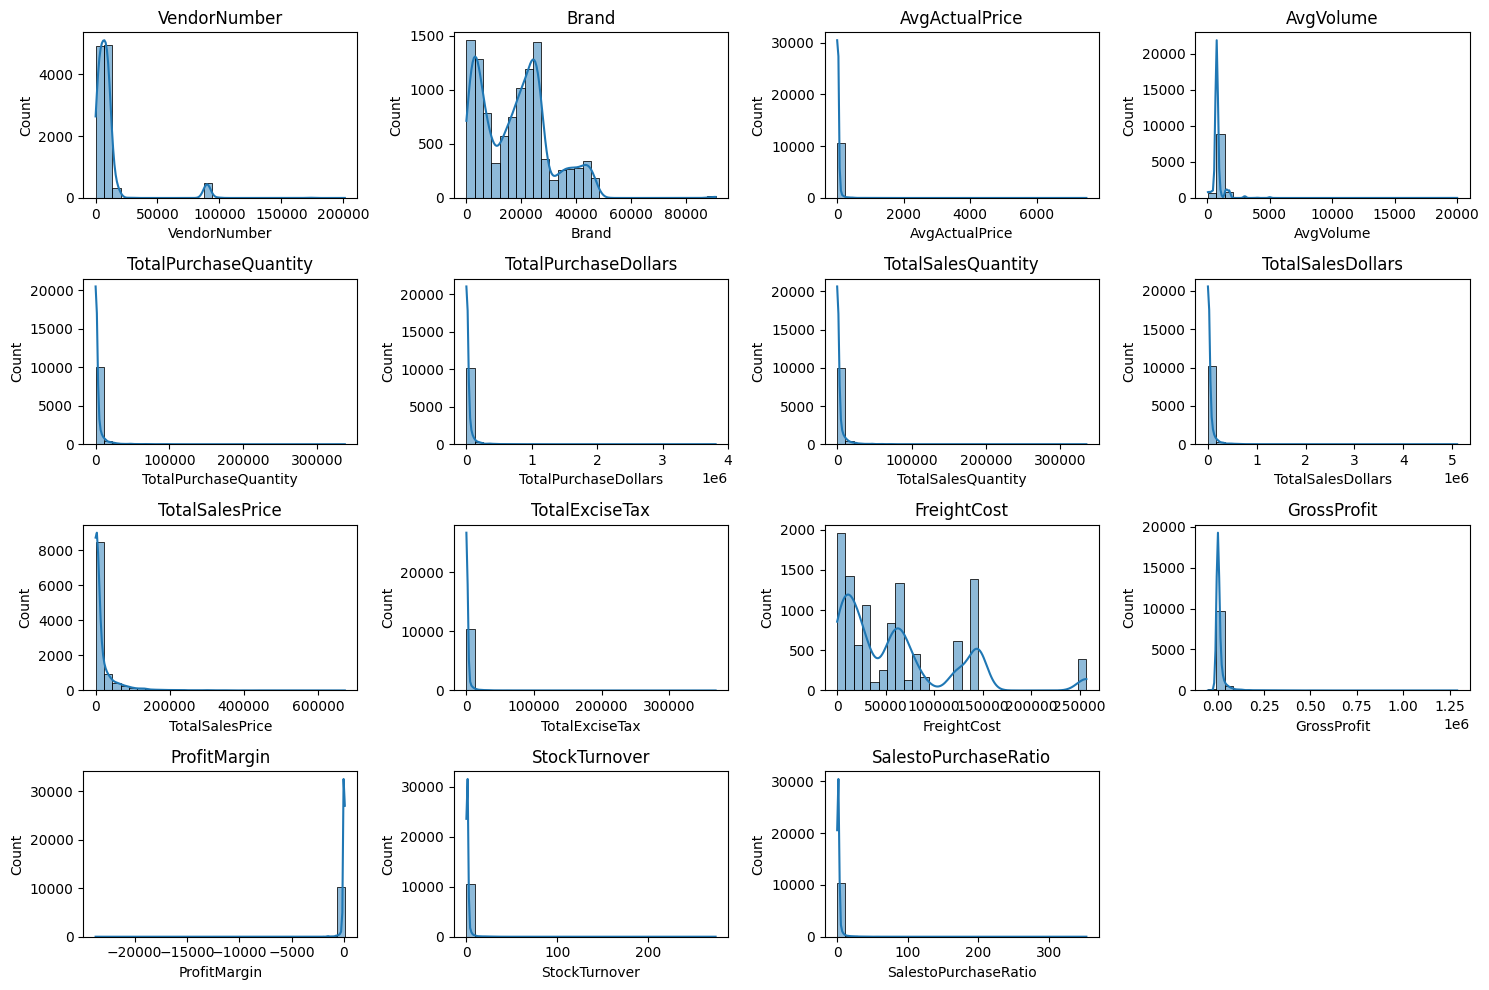

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = vendor_sales.select_dtypes(include= np.number).columns

plt.figure(figsize =(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(vendor_sales[col], kde= True, bins= 30)
    plt.title(col)
plt.tight_layout()
plt.show()


Creating a box plot for all numercial columns to see the median values and how many outliers are present in each column

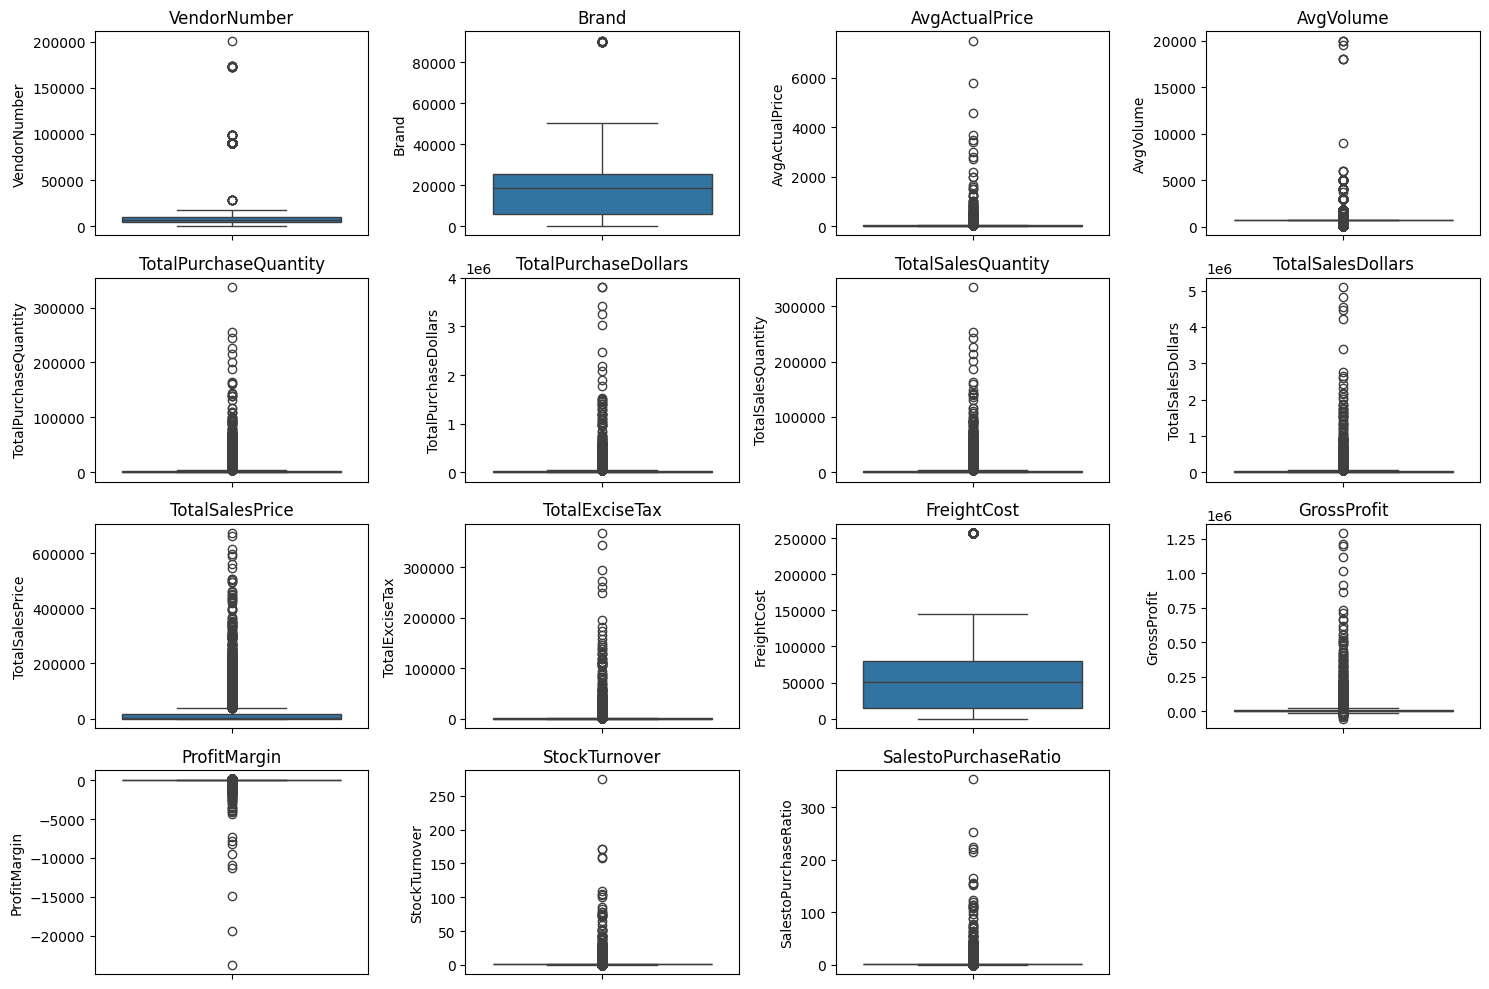

In [128]:
plt.figure(figsize =(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y = vendor_sales[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Summary Statistics Insights:

- Minimum Gross Profit value is -52,003 which indicates a loss. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
- Profit Margin has a minimum value of -23,730, which suggest cases where revenue is even lower than costs.
- Total Sales Quantity and Sales Dollars have minimum values of 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.


- Actual Price column has max value of 7500 which is significantly higher than the mean 35.64 and a high standard deviation of 148, indicating potential premium products.
- Freight Cost also a huge variation from 0.09 to 257,032, suggesting logistics inefficiencies or bulk shipments.
- Stock Turnover ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock.

Filtering the data by removing inconsistencies as there are many outliers which could be due to premium products

In [130]:
query= """Select *
from vendor_sales_summary
where GrossProfit > 0
and ProfitMargin > 0
and TotalSalesQuantity > 0"""

df = pd.read_sql_query(query, db_connection)
df.head()

,VendorNumber,VendorName,Brand,Description,AvgActualPrice,AvgVolume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297692514955152,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062809523586715,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.67578583081817,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.13990840803124,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764200414,0.983556,1.396897


Again checking the distribution of the numerical columns in the dataset

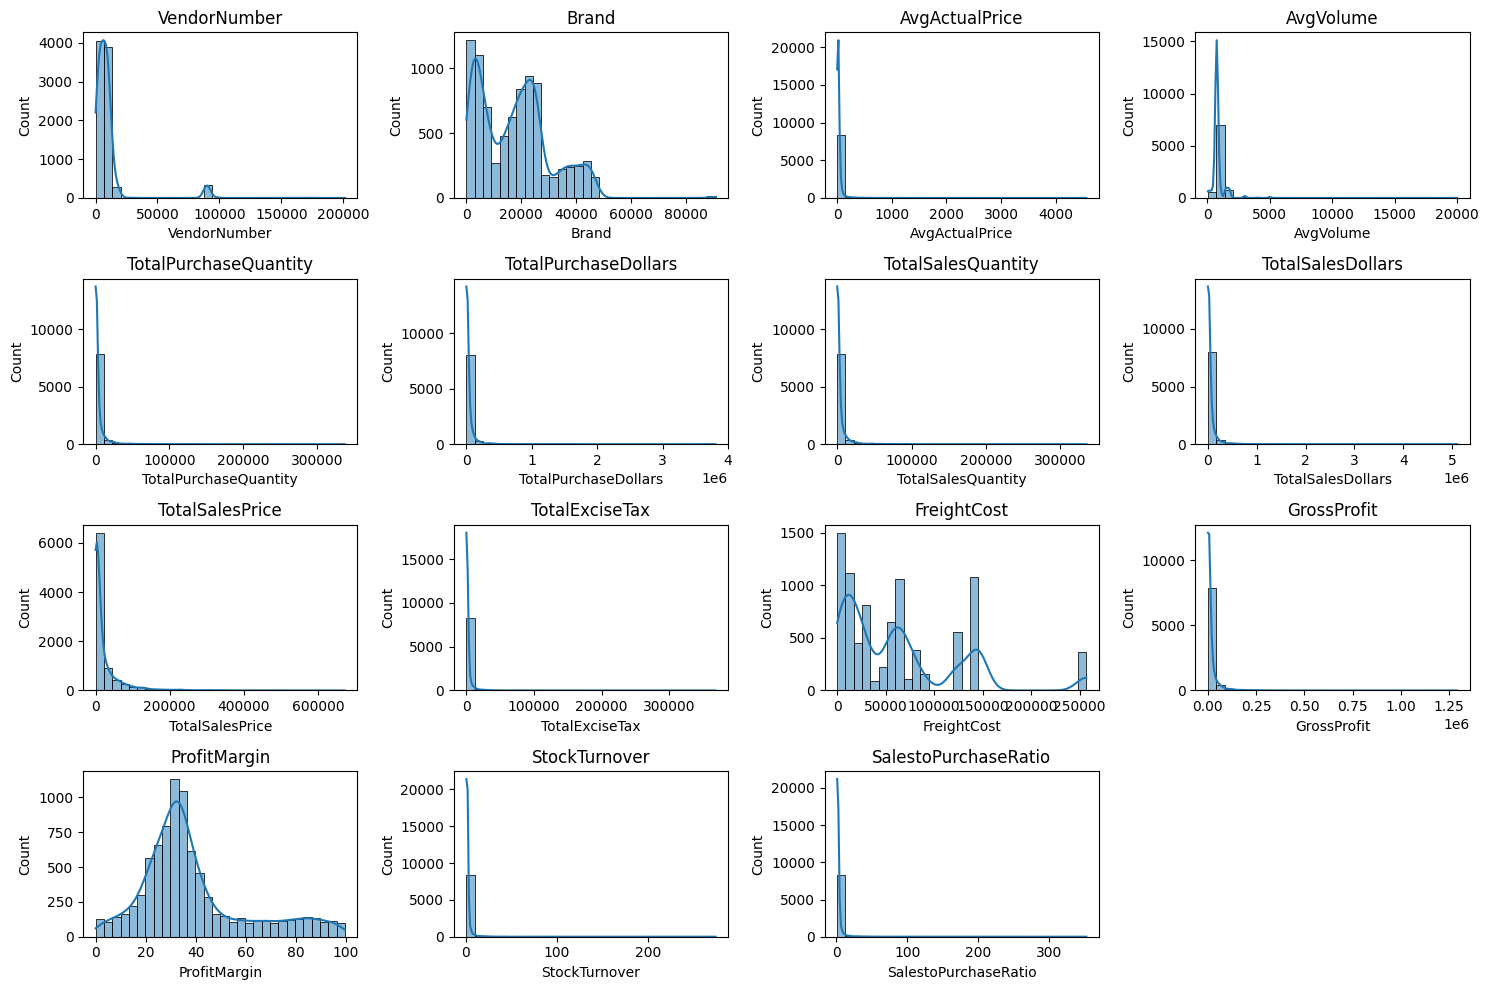

In [133]:
df["ProfitMargin"] = df["ProfitMargin"].astype("float64")

numerical_cols = df.select_dtypes(include= np.number).columns

plt.figure(figsize =(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde= True, bins= 30)
    plt.title(col)
plt.tight_layout()
plt.show()

Creating a Count Plots for Categorical Columns

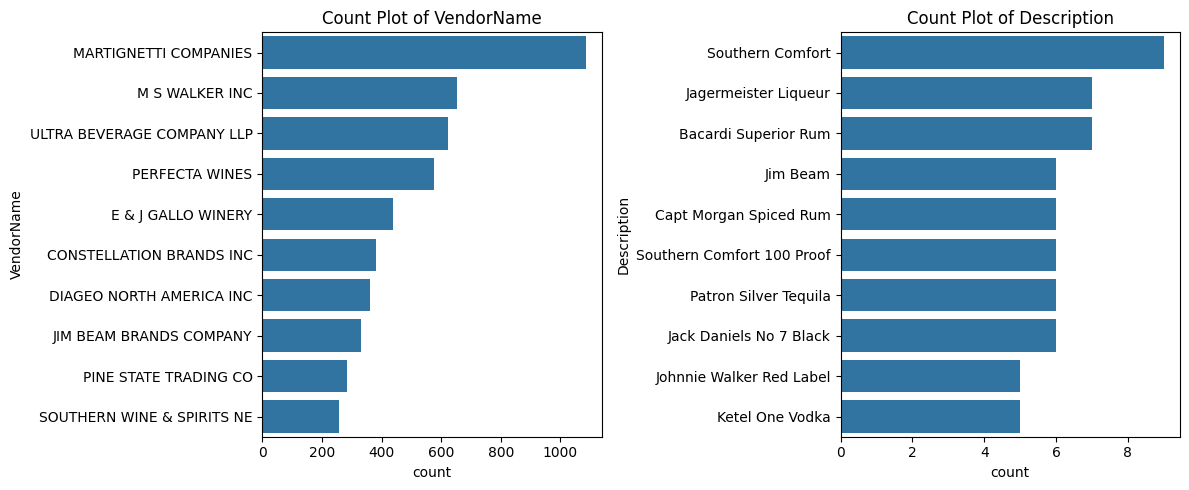

In [136]:
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order= df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

Creating a heatmap to see the correlation between the columns

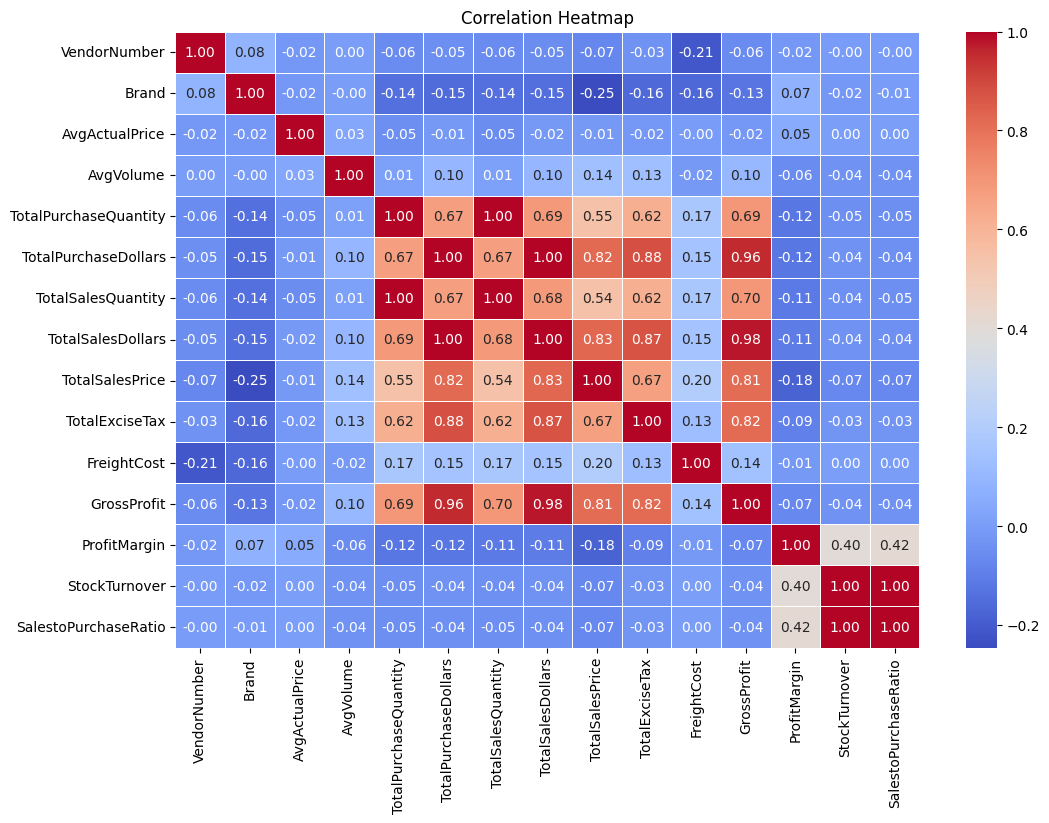

In [141]:
plt.figure(figsize = (12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot= True, fmt=".2f", cmap= "coolwarm", linewidths= 0.5)
plt.title("Correlation Heatmap")
plt.show()

**Correlation Insights**

- Purchase Price has weak correlations with TotalSales Dollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (1.00) which confirms efficient inventory turnover.
- Negative correlation between profit margin and total sales price (-0.18) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- Stock Turnover has weak negative correlations with Gross Profit (-0.04) and moderate positive correlation with Profit Margin (0.40), indicating the faster turnover does not necessarily result in higher profitability.

### Analyzing Brands that needs Promotional or Pricing adjustments (brands with lower sales performance but higher profit margins)

In [143]:
brand_performance = df.groupby("Description").agg({"TotalSalesDollars": "sum", "ProfitMargin": "mean"}).reset_index()
low_sales_thresold = brand_performance["TotalSalesDollars"].quantile(0.15)
high_profit_thresold = brand_performance["ProfitMargin"].quantile(0.85)
print(low_sales_thresold, high_profit_thresold)

560.299 64.97017552750111


Now, filtering the brands with low sales but high profit margins

In [149]:
target_brands = brand_performance[
    (brand_performance["TotalSalesDollars"] <= low_sales_thresold) &
    (brand_performance["ProfitMargin"] >= high_profit_thresold)
]
print("Brands with low Sales but high Profit Margins are: \n")
display(target_brands.sort_values("TotalSalesDollars").reset_index().drop("index", axis=1))

Brands with low Sales but high Profit Margins are: 



,Description,TotalSalesDollars,ProfitMargin
0,Santa Rita Organic Svgn Bl,9.99,66.466466
1,Debauchery Pnt Nr,11.58,65.975820
2,Concannon Glen Ellen Wh Zin,15.95,83.448276
3,Crown Royal Apple,27.86,89.806174
4,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
193,Nanbu Bijin Southern Beauty,535.68,76.747312
194,Dad's Hat Rye Whiskey,538.89,81.851584
195,A Bichot Clos Marechaudes,539.94,67.740860
196,Sbragia Home Ranch Merlot,549.75,66.444748


Creating a scatter plot to visualize how many brands are present above and below the threshold values

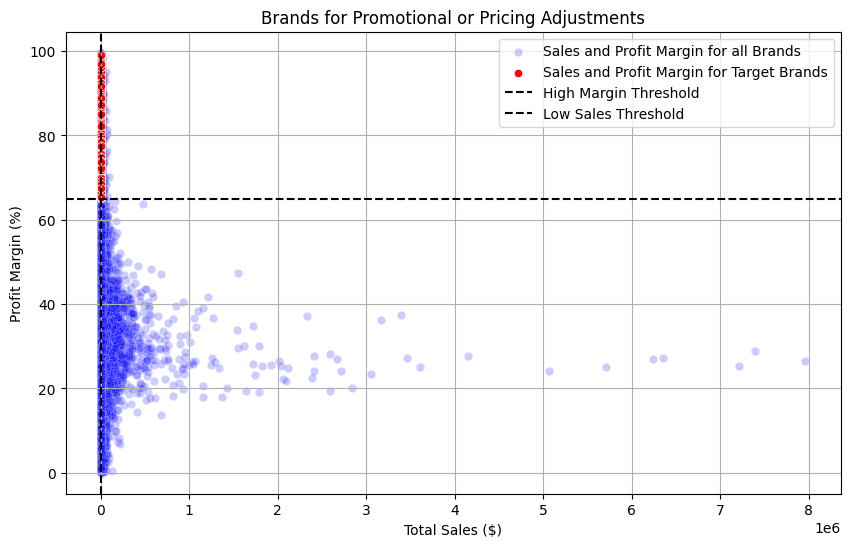

In [150]:
from matplotlib.lines import lineStyles


plt.figure(figsize= (10,6))
sns.scatterplot(data= brand_performance, 
x="TotalSalesDollars",
y= "ProfitMargin", 
color= "blue",
label= "Sales and Profit Margin for all Brands",
alpha = 0.2
)

sns.scatterplot(data= target_brands,
x="TotalSalesDollars",
y= "ProfitMargin", 
color= "red",
label= "Sales and Profit Margin for Target Brands",
)

plt.axhline(high_profit_thresold, linestyle= "--", 
color= "black", label= "High Margin Threshold")
plt.axvline(low_sales_thresold, linestyle= "--", 
color= "black", label= "Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

The graph has many outliers which makes it harder to visualize. Filtering the values for Total Sales less than 10k just for better visualization

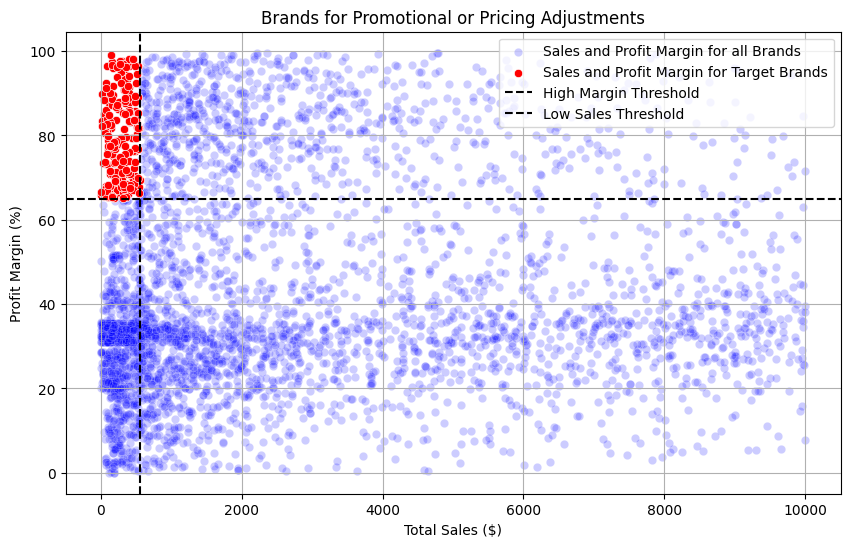

In [151]:
plt.figure(figsize= (10,6))
sns.scatterplot(data= brand_performance[brand_performance["TotalSalesDollars"]<10000], 
x="TotalSalesDollars",
y= "ProfitMargin", 
color= "blue",
label= "Sales and Profit Margin for all Brands",
alpha = 0.2
)

sns.scatterplot(data= target_brands,
x="TotalSalesDollars",
y= "ProfitMargin", 
color= "red",
label= "Sales and Profit Margin for Target Brands",
)

plt.axhline(high_profit_thresold, linestyle= "--", 
color= "black", label= "High Margin Threshold")
plt.axvline(low_sales_thresold, linestyle= "--", 
color= "black", label= "Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Creating the same graph as above using Ploty Express which is more advance and dynamic

In [157]:
target_brands.columns

Index(['Description', 'TotalSalesDollars', 'ProfitMargin'], dtype='object')

In [158]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Filter data
filtered_brands = brand_performance[brand_performance["TotalSalesDollars"] < 10000]

# Create figure
fig = go.Figure()

# Add scatter plots with hover information
fig.add_trace(go.Scatter(
    x=filtered_brands["TotalSalesDollars"],
    y=filtered_brands["ProfitMargin"],
    mode='markers',
    name='All Brands',
    text=filtered_brands["Description"],  # This will show on hover
    hovertemplate="<b>Brand:</b> %{text}<br>" +
                 "<b>Sales:</b> $%{x:,.0f}<br>" +
                 "<b>Profit Margin:</b> %{y:.1f}%<extra></extra>",
    marker=dict(
        color='blue',
        opacity=0.4,
        size=8
    )
))

fig.add_trace(go.Scatter(
    x=target_brands["TotalSalesDollars"],
    y=target_brands["ProfitMargin"],
    mode='markers',
    name='Target Brands',
    text=target_brands["Description"],  # This will show on hover
    hovertemplate="<b>Brand:</b> %{text}<br>" +
                 "<b>Sales:</b> $%{x:,.0f}<br>" +
                 "<b>Profit Margin:</b> %{y:.1f}%<extra></extra>",
    marker=dict(
        color='red',
        size=10,
        line=dict(width=1, color='DarkSlateGrey')
    )
))

# Add threshold lines
fig.add_hline(y=high_profit_thresold, 
              line_dash="dash", 
              line_color="black",
              annotation_text=f"High Margin Threshold ({high_profit_thresold}%)",
              annotation_position="top right")

fig.add_vline(x=low_sales_thresold, 
              line_dash="dash", 
              line_color="black",
              annotation_text=f"Low Sales Threshold (${low_sales_thresold:,.0f})",
              annotation_position="top right")

# Update layout
fig.update_layout(
    title="Brands for Promotional or Pricing Adjustments",
    xaxis_title="Total Sales ($)",
    yaxis_title="Profit Margin (%)",
    legend_title="Legend",
    hovermode="closest",
    template="plotly_white",
    height=700,
    width=1000,
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

# Add grid
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')

# Show the plot
fig.show()

---

### Analyzing Vendors and Brands that demonstrate the highest sales performance

Identifying the top 10 vendors and brands. For this, I grouped by `VendorName` and `Description` (brand name) separately and calculated the `Total Sales Dollars` for each vendor and brand. Then, I selected the vendor name and brands with top 10 highest Total Sales Dollars.

In [172]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands= df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
print("Top Vendors:")
print(*(x for x in top_vendors.index), sep='\n')
print("\n")
print("Top Brands:")
print(*(x for x in top_brands.index), sep='\n')

Top Vendors:
DIAGEO NORTH AMERICA INC
MARTIGNETTI COMPANIES
PERNOD RICARD USA
JIM BEAM BRANDS COMPANY
BACARDI USA INC
CONSTELLATION BRANDS INC
E & J GALLO WINERY
BROWN-FORMAN CORP
ULTRA BEVERAGE COMPANY LLP
M S WALKER INC


Top Brands:
Jack Daniels No 7 Black
Tito's Handmade Vodka
Grey Goose Vodka
Capt Morgan Spiced Rum
Absolut 80 Proof
Jameson Irish Whiskey
Ketel One Vodka
Baileys Irish Cream
Kahlua
Tanqueray


Formating the dollars values to make it more readable and interpretable

In [174]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

Visualizing the data through bar plot to see the total sales dollars for top 10 vendors and brands

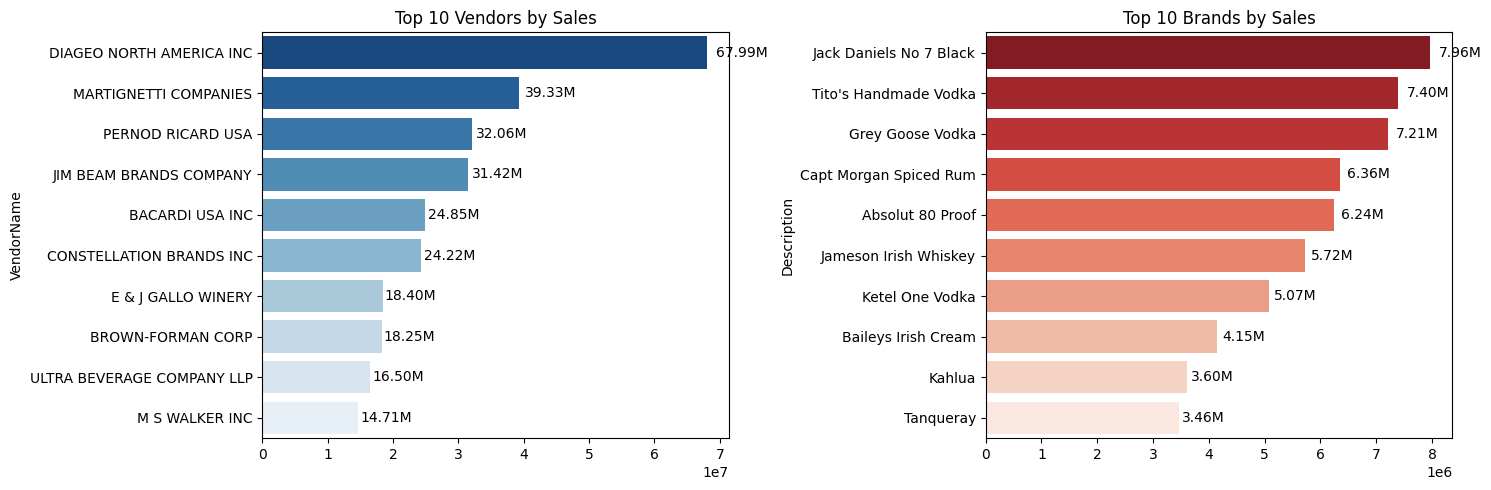

In [177]:
plt.figure(figsize=(15,5))

# Top Vendors Bar plot
plt.subplot(1,2, 1)
ax1= sns.barplot(y= top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() +(bar.get_width() * 0.02),
    bar.get_y() + bar.get_height()/2,
    format_dollars(bar.get_width()),
    ha= "left", va= "center", fontsize= 10, color="black")

# Top Brand Bar plot
plt.subplot(1,2, 2)
ax2= sns.barplot(y= top_brands.index, x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() +(bar.get_width() * 0.02),
    bar.get_y() + bar.get_height()/2,
    format_dollars(bar.get_width()),
    ha= "left", va= "center", fontsize= 10, color="black")

plt.tight_layout()
plt.show()

As noticed, `Diageo North America Inc` is the highest vendor by sales of 68 million units, followed by `Martignetti Companies` with 39.3 million units and `Pernod Ricard USA` with 32 million units.

Similarly, `Jack Daniels No 7 Black` is the highest brand by sales of 7.96 million units, followed by `Tito's Handmade Vodka` and `Grey Goose Vodka`.

Creating a dynamic version of the above graph which are more interactive using Plotly Express

In [185]:
# Create subplots
fig = make_subplots(rows=1, cols=2, 
                   subplot_titles=("Top 10 Vendors by Sales", "Top 10 Brands by Sales"),
                   horizontal_spacing=0.2)

# Add Vendor bars
fig.add_trace(
    go.Bar(
        y=top_vendors.index,
        x=top_vendors.values,
        orientation='h',
        marker_color='#1f77b4',  # Blue color
        name='Vendors',
        hovertemplate='<b>%{y}</b><br>Sales: %{x:$,.0f}<extra></extra>',
        text=[f'${x}' for x in top_vendors.apply(lambda x: format_dollars(x)).values],
        textposition='outside'
    ),
    row=1, col=1
)

# Add Brand bars
fig.add_trace(
    go.Bar(
        y=top_brands.index,
        x=top_brands.values,
        orientation='h',
        marker_color='#d62728',  # Red color
        name='Brands',
        hovertemplate='<b>%{y}</b><br>Sales: %{x:$,.0f}<extra></extra>',
        text=[f'${x}' for x in top_brands.apply(lambda x: format_dollars(x)).values],
        textposition='outside'
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    showlegend=False,
    height=500,
    width=1200,
    margin=dict(l=50, r=50, t=80, b=80),
    xaxis=dict(
        title_text="Total Sales ($)",
        showgrid=True,
        gridwidth=1,
        gridcolor='LightGrey'
    ),
    xaxis2=dict(
        title_text="Total Sales ($)",
        showgrid=True,
        gridwidth=1,
        gridcolor='LightGrey'
    ),
    yaxis=dict(
        autorange="reversed",  # This makes the highest bar appear at the top
        showgrid=False
    ),
    yaxis2=dict(
        autorange="reversed",  # This makes the highest bar appear at the top
        showgrid=False
    ),
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

# Adjust text positions and sizes
fig.update_traces(
    textfont_size=12,
    textangle=0,
    textposition="outside",
    cliponaxis=False
)

# Show the plot
fig.show();

---
### Analyzing vendors that contribute the most to total purchase dollars

Grouping the vendors and calculating the sum of `TotalPurchaseDollars`, `GrossProfit`, and `TotalSalesDollars`. Using this values, I calculated the Purchase Contribution for each vendor by dividing the each Total Purchase Dollars by the Total Purchase Dollars by all vendors to get the contribution to purchase for each vendor. I added the `PurchaseContribution%` back to the table.

In [187]:
vendor_performance= df.groupby("VendorName").agg(
    {"TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "TotalSalesDollars": "sum"}
).reset_index()

vendor_performance["PurchaseContribution%"] = vendor_performance["TotalPurchaseDollars"]/ vendor_performance["TotalPurchaseDollars"].sum() * 100

Sorting the `PurchaseContribution%` in descending order to see the top vendors and rounding the value to 2 decimal places.

In [192]:
round(vendor_performance.sort_values("PurchaseContribution%", ascending= False).reset_index().drop("index", axis=1), 2)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
1,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
2,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
3,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
4,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
...,...,...,...,...,...
114,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
115,UNCORKED,118.74,58.20,176.94,0.00
116,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
117,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


I selected only the top 10 vendors and formatted the values to make it more readable using the format_dollars() function

In [193]:
top_10_vendors = round(vendor_performance.sort_values("PurchaseContribution%", ascending= False).reset_index().drop("index", axis=1), 2).head(10)
top_10_vendors["TotalSalesDollars"] = top_10_vendors["TotalSalesDollars"].apply(format_dollars)
top_10_vendors["TotalPurchaseDollars"] = top_10_vendors["TotalPurchaseDollars"].apply(format_dollars)
top_10_vendors["GrossProfit"] = top_10_vendors["GrossProfit"].apply(format_dollars)
top_10_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
1,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
2,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
3,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
4,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
5,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
6,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
7,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
8,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
9,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [195]:
vendor_performance.shape

(119, 5)

There are total 119 vendors in the orginial dataset. Checking how much just the top 10 vendors purchase compared to 119 vendors

In [198]:
round(top_10_vendors["PurchaseContribution%"].sum().item(0), 2)

65.69

Just the top 10 vendors purchase 65.7% of products from the 119 total vendors

Creating a Pareto Chart to visualize this. Pareto chart displays data in a bar graph format, sorted from highest to lowest frequency, and includes a cumulative line to highlight the most significant contributors to a problem. It is based on the Pareto principle, which suggests that roughly 80% of effects come from 20% of causes. This principle helps identify the "vital few" factors that warrant the most attention in problem-solving. 

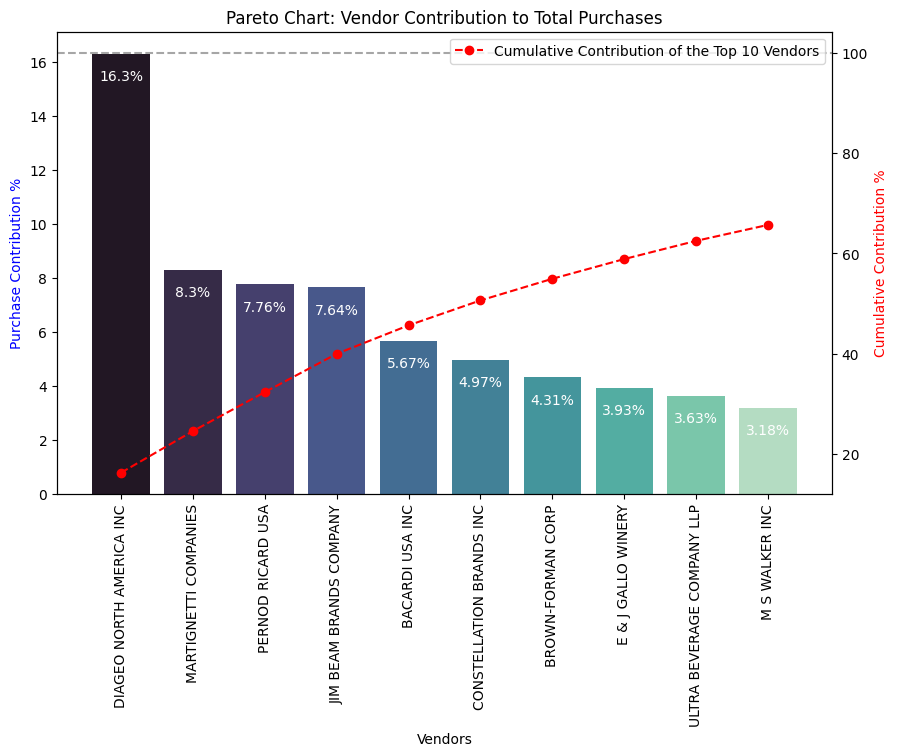

In [203]:
top_10_vendors["Cumulative_Contribution%"] = top_10_vendors["PurchaseContribution%"].cumsum()

# Bar plot for Purchase Contribution %
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(x= top_10_vendors["VendorName"],
y= top_10_vendors["PurchaseContribution%"],
palette="mako",
ax=ax1)

for i, value in enumerate(top_10_vendors["PurchaseContribution%"]):
    ax1.text(i, value-1, str(value) + "%", 
    ha = "center", fontsize=10, color="white")

# Line Plot for Cumulative Contribution %
ax2 = ax1.twinx()
ax2.plot(top_10_vendors["VendorName"], 
    top_10_vendors["Cumulative_Contribution%"], 
    color="red",
    marker="o", 
    linestyle="dashed",
    label= "Cumulative Contribution of the Top 10 Vendors")

ax1.set_xticklabels(top_10_vendors["VendorName"], rotation= 90)
ax1.set_ylabel("Purchase Contribution %", color= "blue")
ax2.set_ylabel("Cumulative Contribution %", color="red")
ax1.set_xlabel("Vendors")
ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchases")

ax2.axhline(y= 100, color= "gray", linestyle= "dashed", alpha=0.7)
ax2.legend(loc= "upper right")

plt.show()


---

### Analyzing Total Procurement dependency on the top Vendors

Creating a Donut Chart to show the Purchase Contribution of top 10 vendors compared to other vendors

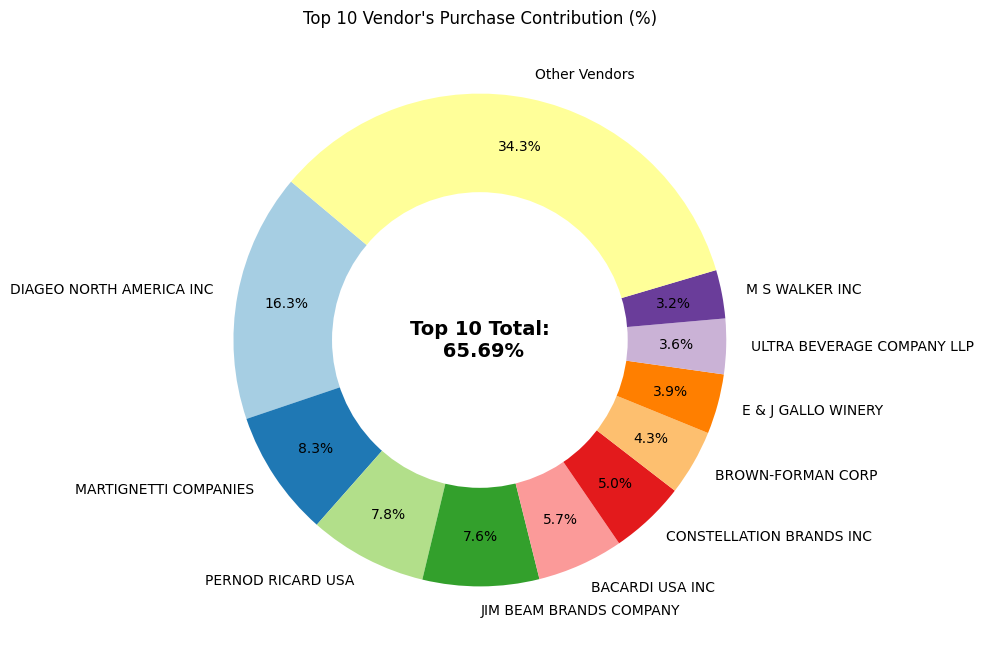

In [208]:
vendors = list(top_10_vendors["VendorName"].values)
purchase_contributions = list(top_10_vendors["PurchaseContribution%"].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Appending "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart for Top 10 vendor contribution vs Other Vendor contribution
fig, ax = plt.subplots(figsize= (8,8))
wedges, texts, autotexts= ax.pie(purchase_contributions, labels= vendors, autopct= "%1.1f%%",
startangle= 140, pctdistance= 0.8, colors= plt.cm.Paired.colors)

center_circle = plt.Circle((0, 0), 0.60, fc="white")
fig.gca().add_artist(center_circle)

plt.text(0, 0, f"Top 10 Total:\n {total_contribution:.2f}%", fontsize= 14, fontweight= "bold",
        ha= "center", va= "center")

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

---
### Analyzing whether purchasing in bulk reduce the unit price and the optimal purchase volume for cost savings

Calculating the per unit Purchase Price for each vendor by dividing the each Total Purchase Dollars with the corrosponding Total Purchase Quantity

In [209]:
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

I splitted the order size into 3 categories as Small, Medium, and Large.

In [210]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])
df[["OrderSize", "TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,Large,145080.0
1,Large,164038.0
2,Large,187407.0
3,Large,201682.0
4,Large,138109.0
...,...,...
8560,Small,2.0
8561,Small,6.0
8562,Small,2.0
8563,Small,1.0


Getting the mean of the unique purchase prices for each of the order size category

In [211]:
df.groupby("OrderSize")[["UnitPurchasePrice"]].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


Creating a boxplot to visualize the distribution of Unit Purchase Price for each category

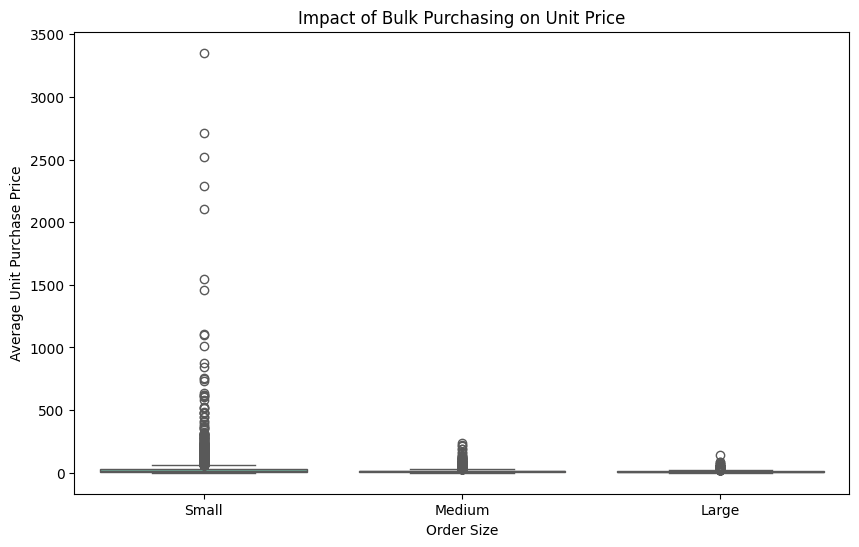

In [212]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x="OrderSize", y="UnitPurchasePrice", palette= "Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

---

### Analyzing vendors with low inventory turnover to indicate excess stock and slow moving products

Getting the vendor name where the Stock Turn Over was less than 1, meaning the number of product sold was less than the number of product purchased. I grouped the data by Vendor Name to get unique values and took the mean of the StockTurnover. Then, I sorted the valued by StockTurnover and displayed the top 5 rows.

In [247]:
df[df["StockTurnover"] < 1].groupby("VendorName")[["StockTurnover"]].mean().sort_values("StockTurnover").head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


---

### Analyzing Capital that is locked in unsold inventory per vendor and identfying the vendor that contribute the most

Calculating the Unsold Inventory Value by subtracting the Total Purchase Quantity and the Total Sales Quantity to get the total unsold quantity and then multiplied it with Actual Price to get the value of the unsold goods for each vendor. Then, I added the column `UnsoldInventoryValue` back to the table. Finally, calculated the sum of those Unsold Inventory value to get the total unsold stock for all the vendors

In [220]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["AvgActualPrice"]

print("Total Unsold Capital: ", format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital:  3.71M


Grouping by Vendors and calculating the sum of the Unsold Inventory Value to get the total unsold stock for each vendor. Then, I sorted the values by `UnsoldInventoryValue` in descending order and I used the previously created formatting function to make the large values more readable

In [ ]:
# Aggregating Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False).reset_index().drop("index", axis=1)
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
0,DIAGEO NORTH AMERICA INC,984.23K
1,JIM BEAM BRANDS COMPANY,761.21K
2,PERNOD RICARD USA,647.40K
3,WILLIAM GRANT & SONS INC,538.71K
4,E & J GALLO WINERY,369.73K
5,SAZERAC CO INC,273.37K
6,BROWN-FORMAN CORP,247.06K
7,CONSTELLATION BRANDS INC,227.37K
8,MOET HENNESSY USA INC,197.64K
9,MAJESTIC FINE WINES,180.73K


---

### Calculating the 95% confidence intervals for profit margins of top-performing and low-performing vendors

First, I imported the `stats` module from the scipy library to calculate the t_critical value. For the top and low threshold, I calculated the 75% percentile and the 25% percentile. Then, I filtered the dataset to get the top 25% and the bottom 25% based on the Total Sales Dollars and selected the Profit Margin column for the filtered dataset. Then, I created the confidence interval function that returns the mean and confiendence interval boundaries is just mean ± margin of error. 

In [237]:
!pip install -qqq stats
from scipy import stats

top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

def confidence_interval(data, confidence =0.95):
    mean = np.mean(data)
    std_error = np.std(data, ddof = 1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1+ confidence)/2, df=len(data)-1)
    margin_of_error = t_critical * std_error
    return mean, mean- margin_of_error, mean + margin_of_error


Calculating the 95% confidence intervals for both top-performing and low-performing vendors with three values from the previous function: mean profit margin, lower bound, and upper bound of the confidence interval. Then, I plotted the distribution of profit margins for top vendors in blue and added vertical lines for the confidence interval bounds (dashed) and mean (solid). Similarly, I plotted the distribution of low performing vendors in red. I added a title, axis labels, legend to identify each distribution and its statistics, and enabled grid lines for better visibility.

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


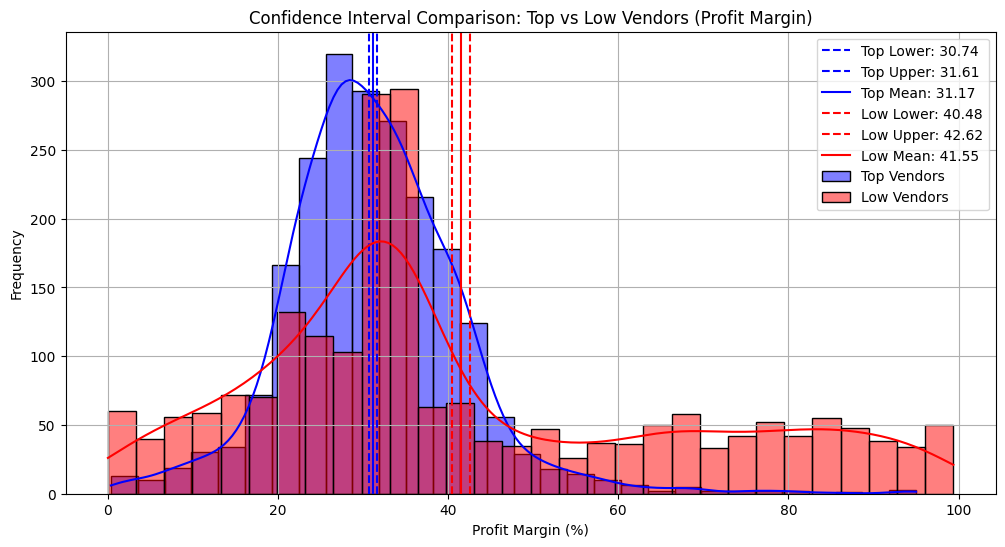

In [238]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize= (12,6))

# Histogram for Top Vendors
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Histograms for Low Vendors
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The cofidence interval for low performing vendors's profit margin (40.48%, 42.62%) is significantly higher than that of top performaing vendor's profit margin (30.74%, 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- If High-Performing Vendors aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- Despite Low-Performing Vendors' higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

### Is there a significant difference in profit margins between top-performing and low-performing vendors?

Now, I did hypothesis testing using the T-test to check whether there is significant difference in the mean profit margins of top and low performing vendors


**H0 (Null Hypothesis):** There is no significant difference in the mean profit margins of top-performing and low-performing vendors. Any observed difference in the samples are random and due to chance.

**H1 (Alternative Hypothesis):** The mean profit margins of top-performing and low-performing vendors are significantly different. Any observed difference in the samples are due to factors other than chance.

$\alpha$ : 0.05

In [243]:
# Performing Two-Sample T-test

t_stat, p_value= stats.ttest_ind(top_vendors, low_vendors, equal_var= False)

print(f"T-Statistic :{round(t_stat, 4)}, P-value: {round(p_value, 3)}\n")

if p_value < 0.05:
    print("""We reject the H0. There is statistically significant evidence to support that 
there is a difference in profit margins between top and low-performing vendors. 
The data is consistent with Alternative Hypothesis. Even if Null Hypothesis is True, there is 5% chance 
of falsely rejecting the Null Hypothesis which is very low by chance.""")
else:
    print("""We fail to reject the H0. The data is consistent with H0 
that there is no significant difference in profit margins between top and low-performing vendors.""")


T-Statistic :-17.644, P-value: 0.0

We reject the H0. There is statistically significant evidence to support that 
there is a difference in profit margins between top and low-performing vendors. 
The data is consistent with Alternative Hypothesis. Even if Null Hypothesis is True, there is 5% chance 
of falsely rejecting the Null Hypothesis which is very low by chance.


Saving the `vendors_sales_summary` and `top_10_vendors` table to csv file which I am going to use in Power BI to make a interactive dashboard.

In [ ]:
vendor_sales.to_csv("vendor_sales_summary.csv", index=False)
top_10_vendors.to_csv("top_10_vendors.csv", index=False)

---

## Author:

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)